# Lab 6 – Machine Learning for Malware Detection  
### Dataset: CIC-MalMem-2022  
### Author: Ruba Al Omari

This lab follows the same overall workflow and format used in the Demo 6 notebook. In the demo, we used the **CIC-MalDroid-2020** dataset. In this lab, you will apply the same machine learning workflow to **CIC-MalMem-2022**.

**Original dataset source:** University of New Brunswick (UNB) – Canadian Institute for Cybersecurity - https://www.unb.ca/cic/datasets/malmem-2022.html

Modified dataset based on the original CIC-MalMem-2022.csv file:
**Lab dataset URL:** `https://raw.githubusercontent.com/rubaomari/mal/refs/heads/main/CIC-MalMem-2022-Modified-RA.csv`

### The following table summarizes the main features extracted from memory for malware detection.

### Table 1. Features in the CIC-MalMem-2022 Dataset

The dataset contains the following features:

**<span style="color: red;">General:</span>**
Category, Class

**<span style="color: red;">Process-related (pslist):</span>**
pslist.nproc, pslist.nppid, pslist.avg_threads, pslist.nprocs64bit, pslist.avg_handlers

**<span style="color: red;">DLL-related (dllist):</span>**
dllist.ndlls, dllist.avg_dlls_per_proc

**<span style="color: red;">Handles:</span>**
handles.nhandles, handles.avg_handles_per_proc, handles.nport, handles.nfile, handles.nevent, handles.ndesktop, handles.nkey, handles.nthread, handles.ndirectory, handles.nsemaphore, handles.ntimer, handles.nsection, handles.nmutant

**<span style="color: red;">Loader modules (ldrmodules):</span>**
ldrmodules.not_in_load, ldrmodules.not_in_init, ldrmodules.not_in_mem, ldrmodules.not_in_load_avg, ldrmodules.not_in_init_avg, ldrmodules.not_in_mem_avg

**<span style="color: red;">Malware injection (malfind):</span>**
malfind.ninjections, malfind.commitCharge, malfind.protection, malfind.uniqueInjections

**<span style="color: red;">Process visibility (psxview):</span>**
psxview.not_in_pslist, psxview.not_in_eprocess_pool, psxview.not_in_ethread_pool, psxview.not_in_pspcid_list, psxview.not_in_csrss_handles, psxview.not_in_session, psxview.not_in_deskthrd,
psxview.not_in_pslist_false_avg, psxview.not_in_eprocess_pool_false_avg, psxview.not_in_ethread_pool_false_avg, psxview.not_in_pspcid_list_false_avg,
psxview.not_in_csrss_handles_false_avg, psxview.not_in_session_false_avg, psxview.not_in_deskthrd_false_avg

**<span style="color: red;">Modules and services:</span>**
modules.nmodules, svcscan.nservices, svcscan.kernel_drivers, svcscan.fs_drivers,
svcscan.process_services, svcscan.shared_process_services, svcscan.interactive_process_services, svcscan.nactive

**<span style="color: red;">Callbacks:</span>**
callbacks.ncallbacks, callbacks.nanonymous, callbacks.ngeneric

### The table below summarizes the malware categories, malware families, and their sample counts in the dataset.

### Table 2. Malware Families and Sample Distribution

| Malware Category | Malware Family | Count | Total Samples |
|------------------|----------------|-------|----------------|
| Trojan Horse | Zeus | 195 | 1950 |
| Trojan Horse | Emotet | 196 | 1967 |
| Trojan Horse | Refroso | 200 | 2000 |
| Trojan Horse | Scar | 200 | 2000 |
| Trojan Horse | Reconyc | 157 | 1570 |
| Spyware | 180Solutions | 200 | 2000 |
| Spyware | Coolwebsearch | 200 | 2000 |
| Spyware | Gator | 200 | 2200 |
| Spyware | Transponder | 241 | 2410 |
| Spyware | TIBS | 141 | 1410 |
| Ransomware | Conti | 200 | 1988 |
| Ransomware | Maze | 195 | 1958 |
| Ransomware | Pysa | 171 | 1717 |
| Ransomware | Ako | 200 | 2000 |
| Ransomware | Shade | 220 | 2128 |

# Instructions

This lab uses a modified version of **CIC-MalMem-2022**. The dataset contains behavioural and memory-related features extracted from malware and benign samples.

### Frame the problem
1. Supervised learning – training examples are labelled.  
2. A classification task – predict a category.  
3. Batch learning.  
    - No continuous flow of data is coming into the system.  
    - No need to adjust to changing data rapidly.  
    - The predictions may be used to help support automated malware triage and analysis.

### What you will predict in this lab
1. **Class** – whether the sample is **Benign** or **Malware**
2. **Malware Category** – the malware category
3. **Malware Family** – the malware family

### Data dictionary / important fields
- **<span style="color: red;">Category</span>**: a string that includes the malware category, malware family, and a unique identifier
- **<span style="color: red;">Class</span>**: the binary label indicating whether the sample is benign or malware
- **<span style="color: red;">Behavioural / memory features</span>**: the remaining columns are numeric features extracted from the sample
- **<span style="color: red;">MalwareCategory and MalwareFamily</span>**: you will extract these from the `Category` column as part of the lab



In [26]:
#import libraries

import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.simplefilter('ignore')

# Task 1 - Load Data & Exploratory Data Analysis

Load the dataset from the URL provided above.

Do **<span style="color: red;">not</span>** download the dataset manually or load it from your local machine at any point in this lab.


### Step 1. Load the Dataset

In [27]:
url = "https://raw.githubusercontent.com/rubaomari/mal/refs/heads/main/CIC-MalMem-2022-Modified-RA.csv"
df = pd.read_csv(url)

### Step 2. Take a Quick Look at the Data Structure

In [28]:
df

,Category,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,...,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class
0,Benign,45,17,10.555556,0,202.844444,1694,38.500000,9129,212.302326,...,221,26,24,116,0,121,87,0,8,Benign
1,Benign,47,19,11.531915,0,242.234043,2074,44.127660,11385,242.234043,...,222,26,24,118,0,122,87,0,8,Benign
2,Benign,40,14,14.725000,0,288.225000,1932,48.300000,11529,288.225000,...,222,26,27,118,0,120,88,0,8,Benign
3,Benign,32,13,13.500000,0,264.281250,1445,45.156250,8457,264.281250,...,222,26,27,118,0,120,88,0,8,Benign
4,Benign,42,16,11.452381,0,281.333333,2067,49.214286,11816,281.333333,...,222,26,24,118,0,124,87,0,8,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58591,Ransomware-Shade-fa03be3078d1b9840f06745f160eb...,37,15,10.108108,0,215.486487,1453,39.270270,7973,215.486487,...,221,26,24,116,0,120,86,0,8,Malware
58592,Ransomware-Shade-f56687137caf9a67678cde91e4614...,37,14,9.945946,0,190.216216,1347,36.405405,7038,190.216216,...,221,26,24,116,0,116,88,0,8,Malware
58593,Ransomware-Shade-faddeea111a25da4d0888f3044ae9...,38,15,9.842105,0,210.026316,1448,38.105263,7982,215.729730,...,221,26,24,116,0,120,88,0,8,Malware
58594,Ransomware-Shade-f866c086af2e1d8ebaa6f2c863157...,37,15,10.243243,0,215.513513,1452,39.243243,7974,215.513513,...,221,26,24,116,0,120,87,0,8,Malware



#### Use **`head()`** to look at the first 5 rows, you can also choose to look at more than the first 5 rows using `head(10)`.


In [29]:
df.head(5)

,Category,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,...,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class
0,Benign,45,17,10.555556,0,202.844444,1694,38.500000,9129,212.302326,...,221,26,24,116,0,121,87,0,8,Benign
1,Benign,47,19,11.531915,0,242.234043,2074,44.127660,11385,242.234043,...,222,26,24,118,0,122,87,0,8,Benign
2,Benign,40,14,14.725000,0,288.225000,1932,48.300000,11529,288.225000,...,222,26,27,118,0,120,88,0,8,Benign
3,Benign,32,13,13.500000,0,264.281250,1445,45.156250,8457,264.281250,...,222,26,27,118,0,120,88,0,8,Benign
4,Benign,42,16,11.452381,0,281.333333,2067,49.214286,11816,281.333333,...,222,26,24,118,0,124,87,0,8,Benign


#### Use the **`describe()`** method to see a summary of the numerical attributes.

In [30]:
df.describe()

,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nport,...,svcscan.nservices,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric
count,58596.000000,58596.000000,58589.000000,58596.0,58596.000000,58596.000000,58596.000000,5.859600e+04,58596.000000,58596.0,...,58596.000000,58596.000000,58596.000000,58596.000000,58596.000000,58596.0,58596.000000,58596.000000,58596.000000,58596.000000
mean,41.394771,14.713837,11.341492,0.0,247.509819,1810.805447,43.707806,1.025858e+04,249.560958,0.0,...,391.347549,221.406581,25.996245,25.063417,116.879514,0.0,121.995546,86.905659,0.000853,7.999881
std,5.777249,2.656748,1.588203,0.0,111.857790,329.782639,5.742023,4.866864e+03,145.999866,0.0,...,4.529704,1.991087,0.170790,1.529628,1.550401,0.0,2.822858,3.134117,0.029199,0.010929
min,21.000000,8.000000,1.650000,0.0,34.962500,670.000000,7.333333,3.514000e+03,71.139241,0.0,...,94.000000,55.000000,6.000000,7.000000,26.000000,0.0,30.000000,50.000000,0.000000,7.000000
25%,40.000000,12.000000,9.972973,0.0,208.725000,1556.000000,38.833333,8.393000e+03,209.648228,0.0,...,389.000000,221.000000,26.000000,24.000000,116.000000,0.0,121.000000,87.000000,0.000000,8.000000
50%,41.000000,15.000000,11.000000,0.0,243.963710,1735.000000,42.781524,9.287500e+03,247.208951,0.0,...,389.000000,221.000000,26.000000,24.000000,116.000000,0.0,122.000000,87.000000,0.000000,8.000000
75%,43.000000,16.000000,12.861858,0.0,289.974322,2087.000000,49.605280,1.219300e+04,291.355050,0.0,...,395.000000,222.000000,26.000000,27.000000,118.000000,0.0,123.000000,88.000000,0.000000,8.000000
max,240.000000,72.000000,16.818182,0.0,24845.951220,3443.000000,53.170732,1.047310e+06,33784.193550,0.0,...,395.000000,222.000000,26.000000,27.000000,118.000000,0.0,129.000000,89.000000,1.000000,8.000000


#### Use **`info()`** to get a quick description of the data, the total number of rows, each attribute’s type, and the number of non-null values.


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58596 entries, 0 to 58595
Data columns (total 57 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Category                                58596 non-null  object 
 1   pslist.nproc                            58596 non-null  int64  
 2   pslist.nppid                            58596 non-null  int64  
 3   pslist.avg_threads                      58589 non-null  float64
 4   pslist.nprocs64bit                      58596 non-null  int64  
 5   pslist.avg_handlers                     58596 non-null  float64
 6   dlllist.ndlls                           58596 non-null  int64  
 7   dlllist.avg_dlls_per_proc               58596 non-null  float64
 8   handles.nhandles                        58596 non-null  int64  
 9   handles.avg_handles_per_proc            58596 non-null  float64
 10  handles.nport                           58596 non-null  in

#### Use **`value_counts`** to show what categories exist and how many rows belong to each Category and to each Class

In [32]:
print(df['Category'].value_counts())
print(df['Class'].value_counts())

Category
Benign                                                                                     29298
Spyware-Gator-1bdcd3b777965f67678748d2577b119a275aca9aed9549d45e64e692a54a7b5e-1.raw           2
Spyware-Gator-1bfb316482877ee42e5a5078fef44c0eb51bc44c1e88ecbccd02ce4dc4694bd3-2.raw           2
Spyware-Gator-1bfb316482877ee42e5a5078fef44c0eb51bc44c1e88ecbccd02ce4dc4694bd3-10.raw          2
Spyware-Gator-1bfb316482877ee42e5a5078fef44c0eb51bc44c1e88ecbccd02ce4dc4694bd3-1.raw           2
                                                                                           ...  
Spyware-Gator-0b25829d15dc951a44e7652fc6de9d936d7d51f29586d56dbf8fccea419252ac-6.raw           1
Spyware-Gator-0b25829d15dc951a44e7652fc6de9d936d7d51f29586d56dbf8fccea419252ac-5.raw           1
Spyware-Gator-0b25829d15dc951a44e7652fc6de9d936d7d51f29586d56dbf8fccea419252ac-4.raw           1
Spyware-Gator-0b25829d15dc951a44e7652fc6de9d936d7d51f29586d56dbf8fccea419252ac-3.raw           1
Ransomware-Shade-955d

### Step 3. Plot a Pie Chart of the Data Classes

Use autopct='%1.1f%%'

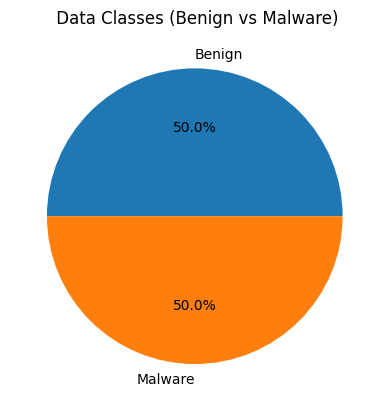

In [33]:
df['Class'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    title=' Data Classes (Benign vs Malware)'
)
plt.ylabel('')
plt.show()

# Task 2 - Prepare the Data for ML Algorithms

### Step 4. Extract `MalwareCategory` and `MalwareFamily` from `Category`

The `Category` field includes the malware category, malware family, and a unique identifier. Expand it into the new columns.

In [34]:
df['MalwareCategory'] = df['Category'].str.split('-').str[0]
df['MalwareFamily'] = df['Category'].str.split('-').str[1]
df[['Category', 'MalwareCategory', 'MalwareFamily']].tail(10)

,Category,MalwareCategory,MalwareFamily
58586,Ransomware-Shade-f0263b44ed76e6df5066f7e86857a...,Ransomware,Shade
58587,Ransomware-Shade-f7486997c398862fbaef51dc1207d...,Ransomware,Shade
58588,Ransomware-Shade-faddeea111a25da4d0888f3044ae9...,Ransomware,Shade
58589,Ransomware-Shade-fcc27646dfd9292f55edc8de25311...,Ransomware,Shade
58590,Ransomware-Shade-f7486997c398862fbaef51dc1207d...,Ransomware,Shade
58591,Ransomware-Shade-fa03be3078d1b9840f06745f160eb...,Ransomware,Shade
58592,Ransomware-Shade-f56687137caf9a67678cde91e4614...,Ransomware,Shade
58593,Ransomware-Shade-faddeea111a25da4d0888f3044ae9...,Ransomware,Shade
58594,Ransomware-Shade-f866c086af2e1d8ebaa6f2c863157...,Ransomware,Shade
58595,Ransomware-Shade-955d9af38346c1755527bd196668e...,Ransomware,Shade


### Step 5. Remove Specific Columns
Drop the following columns:
1. Category
2. pslist.nprocs64bit
3. handles.nport
4. svcscan.interactive_process_services

In [35]:
df = df.drop(columns=['Category', 'pslist.nprocs64bit', 'handles.nport', 'svcscan.interactive_process_services'])

### Step 6. Check for Duplicate Rows
Check for duplicate rows and remove them.

In [36]:
df.duplicated().sum()

549

In [37]:
df = df.drop_duplicates()

### Step 7. Inspect Missing Values
Check the number of missing values.

For missing values, use the **mean** for numerical features.  
We will implement this using a **pipeline**, which will also handle **feature scaling** in the next step.

In [38]:
df.isna().sum()

pslist.nproc                                  0
pslist.nppid                                  0
pslist.avg_threads                            7
pslist.avg_handlers                           0
dlllist.ndlls                                 0
dlllist.avg_dlls_per_proc                     0
handles.nhandles                              0
handles.avg_handles_per_proc                  0
handles.nfile                                 0
handles.nevent                                0
handles.ndesktop                              8
handles.nkey                                  0
handles.nthread                               0
handles.ndirectory                            0
handles.nsemaphore                            0
handles.ntimer                                0
handles.nsection                              0
handles.nmutant                               5
ldrmodules.not_in_load                        0
ldrmodules.not_in_init                        4
ldrmodules.not_in_mem                   

# Task 3 - Split the Dataset Into Train and Test Datasets

### Step 8. Split the Dataset into Training and Testing Sets

Use `stratify=y` to ensure the same class distribution in train and test sets (e.g., if Class 1 is 10% in the full data -> ~10% in both splits).

> **Important:** For this task, do **not** include `MalwareCategory` or `MalwareFamily` as input features when predicting `Class`, since they are target-related fields and would leak label information into the model.

In [39]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Class', 'MalwareCategory', 'MalwareFamily'])
y= df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (46437, 52)
X_test : (11610, 52)
y_train: (46437,)
y_test : (11610,)


### Step 9. Create and Apply a Preprocessing Pipeline
Since all features are numerical, we will apply imputation and scaling using a single preprocessing pipeline.
Create a preprocessing pipeline to:
1. Fill in missing numerical values with the mean using `SimpleImputer`
2. Scale the numerical columns using `StandardScaler`


In [40]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

#numerical-only preprocessing
preprocessing = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

X_train_prepared = preprocessing.fit_transform(X_train)
X_test_prepared = preprocessing.transform(X_test)

feature_names = X_train.columns

X_train_prepared = pd.DataFrame(X_train_prepared, columns=feature_names)
X_test_prepared = pd.DataFrame(X_test_prepared, columns=feature_names)

### Step 10. Print the Shapes of X_train_prepared and X_test_prepared

In [41]:
print("X_train_prepared:", X_train_prepared.shape)
print("X_test_prepared :", X_test_prepared.shape)

X_train_prepared: (46437, 52)
X_test_prepared : (11610, 52)


### Step 11. Display Your Pipeline

In [42]:
preprocessing

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler())])

# Task 4 - Create Backup

### Step 12. Create Backup

In [43]:
df_backup = df.copy()

# Task 5 - Select a Model and Train it to Predict Class

### Step 13. Train a LogisticRegression Classifier

Train a `LogisticRegression` classifier to predict the class label using the training set and `max_iter=1000` and `class_weight="balanced"`

In [44]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train_prepared, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

### Step 14. Test your Model

Test your model on `X_test_prepared`, and report the `classification_report` using `y_test` and `y_predict_lr`.

In [45]:
from sklearn.metrics import classification_report
y_predict_lr = lr.predict(X_test_prepared)
print(classification_report(y_test, y_predict_lr))

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5847
     Malware       1.00      1.00      1.00      5763

    accuracy                           1.00     11610
   macro avg       1.00      1.00      1.00     11610
weighted avg       1.00      1.00      1.00     11610



### Step 15. Plot the Confusion Matrix of your Test Results

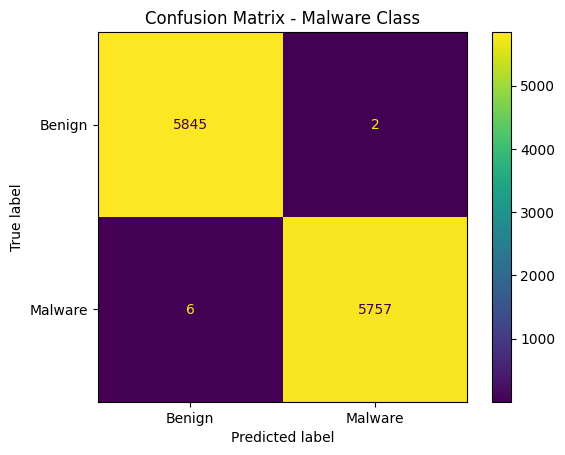

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_predict_lr)
plt.title("Confusion Matrix - Malware Class")
plt.show()

# Task 6 - Predict Malware Category

Use a `LogisticRegression` classifier to predict `MalwareCategory`. Before training, drop `Class` and `MalwareFamily` from the input features.

For this task, report the `classification_report` and plot the confusion matrix

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5847
  Ransomware       0.46      0.44      0.45      1905
     Spyware       0.59      0.38      0.46      1962
      Trojan       0.44      0.63      0.52      1896

    accuracy                           0.74     11610
   macro avg       0.62      0.61      0.61     11610
weighted avg       0.75      0.74      0.74     11610



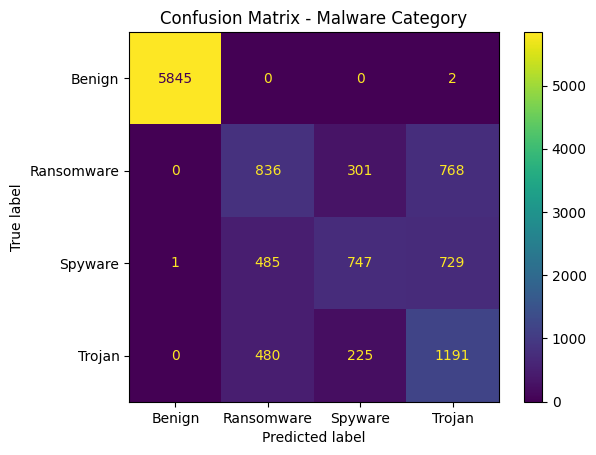

In [47]:
X6 = df.drop(columns=['Class', 'MalwareFamily', 'MalwareCategory'])
y6 = df['MalwareCategory']

X6_train, X6_test, y6_train, y6_test = train_test_split(X6, y6, test_size=0.2, random_state=42, stratify=y6)

preprocessing6 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

X6_train_prepared = preprocessing6.fit_transform(X6_train)
X6_test_prepared = preprocessing6.transform(X6_test)

lr6 = LogisticRegression(max_iter=1000, class_weight="balanced")
lr6.fit(X6_train_prepared, y6_train)

y6_predict = lr6.predict(X6_test_prepared)
print(classification_report(y6_test, y6_predict))

ConfusionMatrixDisplay.from_predictions(y6_test, y6_predict)
plt.title("Confusion Matrix - Malware Category")
plt.show()

# Task 7 - Predict Malware Family

Use a `LogisticRegression` classifier to predict `MalwareFamily`. Before training, drop `Class` and `MalwareCategory` from the input features.

For this task, report the `classification_report` and plot the confusion matrix

              precision    recall  f1-score   support

180solutions       0.26      0.12      0.16       400
         Ako       0.24      0.16      0.19       400
         CWS       0.34      0.12      0.18       400
       Conti       0.16      0.13      0.14       397
      Emotet       0.22      0.30      0.25       393
       Gator       0.47      0.40      0.44       399
        Maze       0.28      0.26      0.27       351
        Pysa       0.25      0.10      0.14       332
     Reconyc       0.17      0.29      0.22       314
     Refroso       0.29      0.42      0.34       399
        Scar       0.31      0.23      0.26       400
       Shade       0.17      0.18      0.17       425
        TIBS       0.41      0.51      0.46       282
 Transponder       0.26      0.10      0.15       482
        Zeus       0.14      0.41      0.21       390

    accuracy                           0.24      5764
   macro avg       0.26      0.25      0.24      5764
weighted avg       0.26   

<Figure size 3000x2000 with 0 Axes>

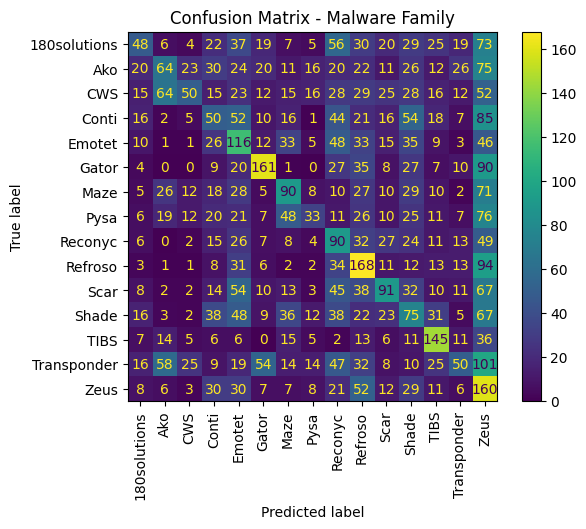

In [48]:
df7 = df.dropna(subset=['MalwareFamily'])
X7 = df7.drop(columns=['Class', 'MalwareFamily', 'MalwareCategory'])
y7 = df7['MalwareFamily']

X7_train, X7_test, y7_train, y7_test = train_test_split(X7, y7, test_size=0.2, random_state=42, stratify=y7)

preprocessing7 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

X7_train_prepared = preprocessing7.fit_transform(X7_train)
X7_test_prepared = preprocessing7.transform(X7_test)

lr7 = LogisticRegression(max_iter=1000, class_weight="balanced")
lr7.fit(X7_train_prepared, y7_train)

y7_predict = lr7.predict(X7_test_prepared)
print(classification_report(y7_test, y7_predict))
plt.figure(figsize=(30, 20))
ConfusionMatrixDisplay.from_predictions(y7_test, y7_predict)
plt.title("Confusion Matrix - Malware Family")
plt.xticks(rotation=90)
plt.show()

# Task 8 - Brief Reflection

Reflect on the performance achieved when predicting **Malware Class**, **Malware Category**, and **Malware Family**.

- Which metric is most important for malware detection and why?
- Which task achieved the highest performance? Why?
- Why does the **Malware Family** classification task usually perform worse than **Class** or **Category** prediction?
- How could the Malware Family results be improved?

Task 8 Answer

**<span style="color: green;">Answer limit:</span>**
Each question must be answered in 2–3 concise sentences (maximum 75-100 words per question).
Responses that are excessively long or vague will lose marks.

Which metric is most important for malware detection and why?
- Recall is the most important metric for detecting malware because it measures how many malware samples are correctly identified. This is because a false negative can lead to a system compromise. Therefore, the less false negatives we have the better it is.

Which task achieved the highest performance? Why?
- Predicting malware class that is Benign vs Malware  achieved the highest performance. This is because it is a very simple classification between two different broad states. Therefore, this makes the decision much easier.

Why does the Malware Family classification task usually perform worse than Class or Category prediction?
- Malware Family classification task usually perform worse than Class or Category prediction because malware family involes many classes with similar behavioral patterns which makes it much harder to differentiate. Malware families betwwen the same category usually also share similar features and patters like memory management. All this makes the classification harder to predict.

How could the Malware Family results be improved?
- Malware family results could be improved by using classifiers that can hanle multiple classes natively like RandomForestClassifier or GaussianNB which capture non-linear relationship better than Logistic Regression We can also collect more balalnced samples per malware family to improve the results.

# Rubric

- Task 1 – Load Data & EDA: **<span style="color: green;">5 Marks</span>**
- Task 2 – Prepare the Data: **<span style="color: green;">5 Marks</span>**
- Task 3 – Split + Preprocess: **<span style="color: green;">5 Marks</span>**
- Task 4 – Backup: **<span style="color: green;">5 Marks</span>**
- Task 5 – Predict Class: **<span style="color: green;">20 Marks</span>**
- Task 6 – Predict Malware Category: **<span style="color: green;">25 Marks</span>**
- Task 7 – Predict Malware Family: **<span style="color: green;">25 Marks</span>**
- Task 8 – Reflection: **<span style="color: green;">10 Marks</span>**

**Penalty**
- Preprocessing fit on full dataset before train/test split: **<span style="color: red;">−25 Marks</span>**
- Using MalwareCategory or MalwareFamily when predicting Class: **<span style="color: red;">−25 Marks</span>**
- Data leakage (any form): **<span style="color: red;">−25 Marks</span>**
    - (e.g., fitting preprocessing before train/test split, using target-derived features, or leaking test data into training)
- Wrong target variable: **<span style="color: red;">−25 Marks</span>**
- Failure to submit a working GitHub link, or link is not accessible by the TA/Instructor: **<span style="color: red;">−50 Marks</span>**
- Failure to submit a working notebook: **<span style="color: red;">−50 Marks</span>**

# Sample Screenshots
- Task 5:

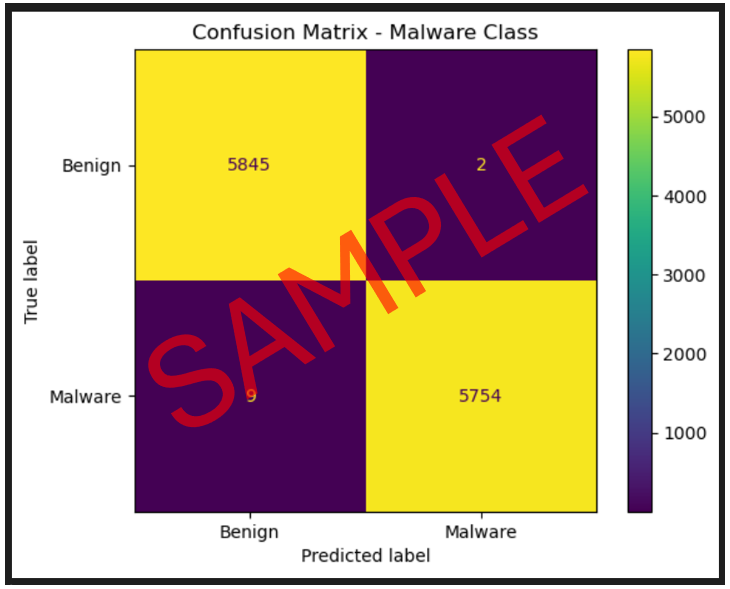
- Task 6:

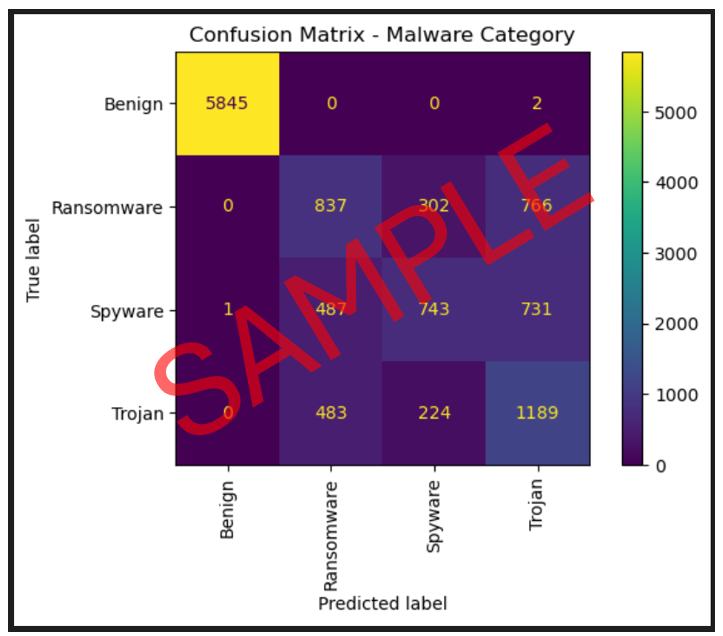


- Task 7:

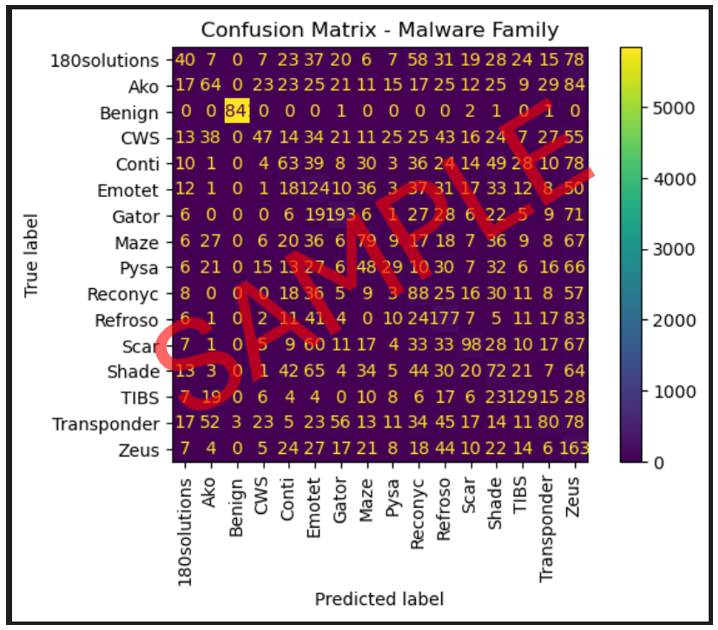




# Submission Instructions

Please complete the following steps for your submission:

1. **<span style="color: red;">Run your notebook and ensure all cells execute successfully</span>**: Save the notebook with all outputs visible.

2. **<span style="color: red;">Notebook requirements:</span>**
   - Submit a clean notebook
   - No errors or warnings
   - No unnecessary or debugging code
   - Only include code relevant to the required tasks
   - Ensure all outputs are visible before submission

3. **<span style="color: red;">Upload your notebook (with outputs) to GitHub</span>**
   - Submit the GitHub URL on eClass as a comment.  
   - In the eClass submission dropbox, paste the GitHub link to your notebook in the Comment field.
   - Make sure your repository where the notebook is, is publicly accessible. 


4. **<span style="color: red;">Submit your `.ipynb` file on eClass</span>** (with outputs included).  
   - Ensure the dataset is loaded from the provided URL (as specified in Task 1).  
   - Do **not** load the dataset from your local machine.  
 

5. **<span style="color: red;">File naming convention:</span>**
   `Lab6-FirstName.ipynb`
